In [98]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler,OneHotEncoder,StandardScaler
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [99]:
df=pd.read_csv('loan_data.csv')
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [100]:
x=df.drop(columns='loan_status')
y=df['loan_status']

In [101]:
num_cols=x.select_dtypes(include='number').columns
obj_cols=x.select_dtypes(include='object').columns
num_cols

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score'],
      dtype='object')

In [102]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [103]:
xtrain[obj_cols].nunique()

person_gender                     2
person_education                  5
person_home_ownership             4
loan_intent                       6
previous_loan_defaults_on_file    2
dtype: int64

<Axes: >

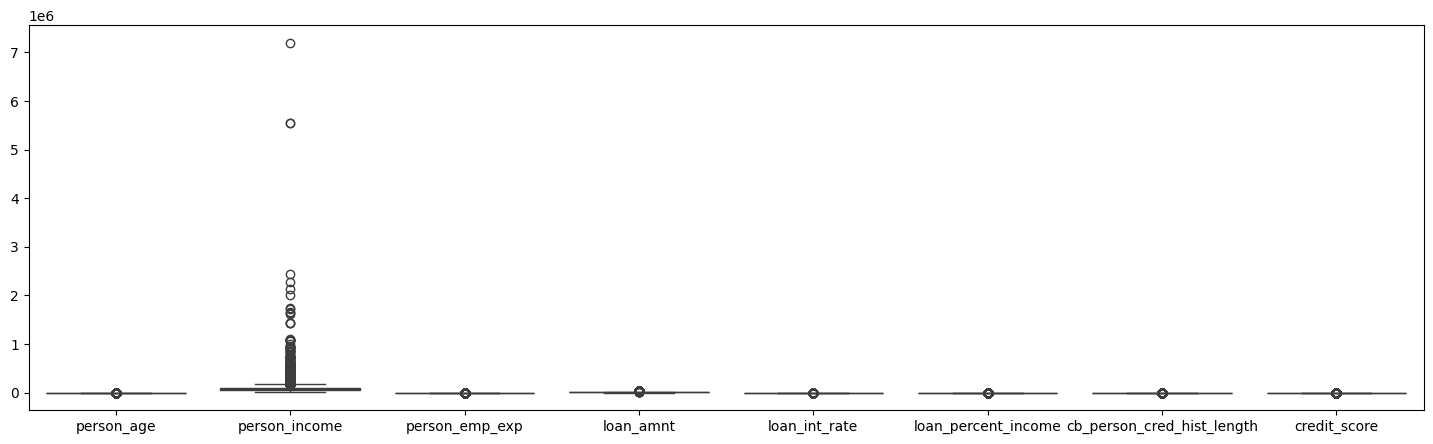

In [104]:
plt.figure(figsize=(18,5))
sns.boxplot(xtrain[num_cols])

In [105]:
preprocessing=ColumnTransformer(
    transformers=[
        ('scaler',RobustScaler(),['person_income']),
        ('stand_scaler',StandardScaler(),['person_age', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']),
       ('encode',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),obj_cols)
        
    ],
    remainder='passthrough'
)

In [106]:
main_pipeline=Pipeline(
    steps=[
        ('preprocessing',preprocessing),
        ('model',KNeighborsClassifier(n_neighbors=5,metric='euclidean'))
    ]
)

In [107]:
main_pipeline.fit(xtrain,ytrain)

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('scaler', ...), ('stand_scaler', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [108]:
ypred_train=main_pipeline.predict(xtrain)

In [109]:
print(classification_report(ytrain,ypred_train))

              precision    recall  f1-score   support

           0       0.94      0.97      0.95     28010
           1       0.87      0.79      0.83      7990

    accuracy                           0.93     36000
   macro avg       0.91      0.88      0.89     36000
weighted avg       0.93      0.93      0.93     36000



In [110]:
ypred_test=main_pipeline.predict(xtest)

In [111]:
print(classification_report(ytest,ypred_test))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      6990
           1       0.80      0.71      0.75      2010

    accuracy                           0.90      9000
   macro avg       0.86      0.83      0.84      9000
weighted avg       0.89      0.90      0.89      9000

